In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(42)
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

### Loading dataset

https://keras.io/api/datasets/mnist/

In [3]:
keras.datasets.mnist.load_data(path="mnist.npz")

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [4]:
(X_train, y_train), (X_test, y_test) = mnist.load_data(path="mnist.npz")

In [5]:
type(X_train), X_train.shape, y_train.shape, X_test.shape, y_test.shape

(numpy.ndarray, (60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [6]:
X_train[10]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  42, 118,
        219, 166, 118, 118,   6,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 103, 242, 254,
        254, 254, 254, 254,  66,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

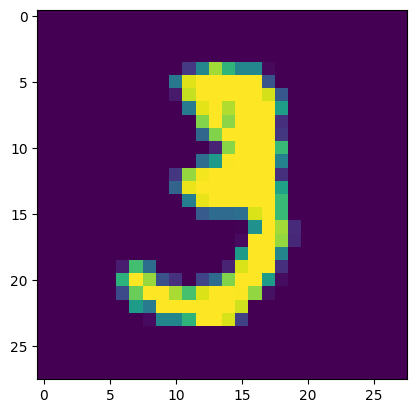

In [7]:
plt.imshow(X_train[10])
plt.show()

In [8]:
# print the corresponding label
print(f"Label: {y_train[10]}")

Label: 3


In [9]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

### Scaling the values

In [10]:
X_train  = X_train / 255.0
X_test = X_test / 255.0

### Build the Neural Network

In [11]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
                metrics=["accuracy"])

model.fit(X_train, y_train, epochs=10)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8450 - loss: 0.6012
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9188 - loss: 0.2837
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9347 - loss: 0.2313
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9443 - loss: 0.1966
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9519 - loss: 0.1705
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9575 - loss: 0.1502
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9621 - loss: 0.1339
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9659 - loss: 0.1207
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9689 - loss: 0.1096
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9719 - loss: 0.1001


In [12]:
Y_pred = model.predict(X_test)
Y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[7.08779407e-05, 4.59570828e-07, 4.36887785e-04, ...,
        9.97188628e-01, 2.37643126e-05, 6.73374452e-05],
       [3.34229000e-04, 5.47187992e-05, 9.98112321e-01, ...,
        2.74587952e-09, 1.82319505e-04, 2.72829137e-09],
       [3.52565112e-05, 9.82239842e-01, 5.99257275e-03, ...,
        5.91977034e-03, 1.92091509e-03, 1.75660316e-04],
       ...,
       [1.01048144e-07, 1.96055652e-08, 1.85754104e-07, ...,
        4.12591471e-04, 5.98212529e-04, 1.60871726e-03],
       [1.02342692e-05, 2.71695194e-06, 1.62734477e-06, ...,
        1.88994079e-07, 2.57664337e-03, 7.69179223e-07],
       [4.70003761e-06, 9.71184999e-09, 2.70106066e-05, ...,
        9.37952827e-10, 1.17003736e-07, 9.20932886e-10]],
      shape=(10000, 10), dtype=float32)

In [13]:
Y_pred[0]

array([7.0877941e-05, 4.5957083e-07, 4.3688779e-04, 2.2055937e-03,
       3.1472004e-07, 6.1808137e-06, 1.3839938e-09, 9.9718863e-01,
       2.3764313e-05, 6.7337445e-05], dtype=float32)

In [14]:
labels = [np.argmax(i) for i in Y_pred]
print(labels)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(6), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(3), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(6), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

In [15]:
y_test

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

### Confusion Matrix

In [16]:
con_matrix = confusion_matrix(y_test, labels)
con_matrix

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 967,    0,    1,    1,    0,    2,    5,    2,    2,    0],
       [   0, 1117,    3,    1,    0,    1,    5,    1,    7,    0],
       [   6,    1, 1005,    3,    3,    0,    3,    7,    4,    0],
       [   1,    0,    8,  976,    0,    8,    0,    9,    5,    3],
       [   1,    0,    5,    0,  942,    0,    8,    3,    2,   21],
       [   7,    1,    0,   10,    1,  853,    9,    1,    6,    4],
       [   6,    3,    1,    1,    4,    8,  934,    0,    1,    0],
       [   0,    7,   14,    3,    1,    1,    0,  994,    1,    7],
       [   3,    0,    5,   10,    3,    6,    8,    8,  929,    2],
       [   5,    6,    1,    8,   13,    1,    1,   12,    1,  961]],
      dtype=int32)>

<Axes: >

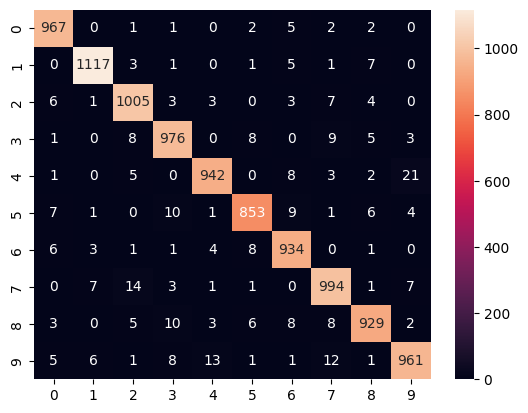

In [17]:
sns.heatmap(con_matrix, annot=True, fmt="d")

In [18]:
image = Image.open("test.png")
img_array = np.array(image)
img_array.shape


(318, 318, 3)

In [19]:
gray_image = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
gray_image.shape

(318, 318)

In [20]:
image_scled = gray_image / 255.0
image_scled_resized = cv2.resize(image_scled, (28, 28))
image_scled_resized.shape

(28, 28)

In [21]:
image_reshaped = image_scled_resized.reshape(1, 28, 28)
image_reshaped.shape

(1, 28, 28)

In [22]:
input_prediction = model.predict(image_reshaped)
input_prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


array([[3.3657048e-07, 9.6768300e-09, 1.2979513e-05, 9.9995589e-01,
        8.2807497e-11, 2.7276198e-07, 7.1790156e-12, 1.9884055e-07,
        6.3338648e-06, 2.3960953e-05]], dtype=float32)

In [23]:
input_prediction_label = np.argmax(input_prediction)
input_prediction_label

np.int64(3)

### **Predective System**

In [32]:
import numpy as np
import cv2
from PIL import Image
import os

# Get image path
image_path = input("Enter the path to the image: ").strip()

# Check if file exists
if not os.path.exists(image_path):
    print("❌ Error: File not found!")
    exit()

try:
    image = Image.open(image_path).convert("RGB")
    img_array = np.array(image)
    gray_image = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    image_resized = cv2.resize(gray_image, (28, 28), interpolation=cv2.INTER_AREA)
    image_scaled = image_resized.astype("float32") / 255.0
    image_reshaped = image_scaled.reshape(1, 28, 28)
    prediction = model.predict(image_reshaped)

    predicted_label = np.argmax(prediction)
    confidence = np.max(prediction)

    print(f"✅ The Handwritten digit is recognised as: {predicted_label}")

except Exception as e:
    print(f"❌ Error processing image: {e}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
✅ The Handwritten digit is recognised as: 3
